In [3]:
#Opening and Plotting netCDF Data
!pip install pythia-datasets

In [4]:
# imports
import numpy as np
import xarray as xr
from pythia_datasets import DATASETS
import matplotlib.pyplot as plt

In [5]:
filepath= DATASETS.fetch("NARR_19930313_0000.nc")

In [6]:
ds = xr.open_dataset(filepath)
ds

<xarray.Dataset> Size: 15MB
Dimensions:                       (time1: 1, isobaric1: 29, y: 119, x: 268)
Coordinates:
  * time1                         (time1) datetime64[ns] 8B 1993-03-13
  * isobaric1                     (isobaric1) float32 116B 100.0 125.0 ... 1e+03
  * y                             (y) float32 476B -3.117e+03 ... 714.1
  * x                             (x) float32 1kB -3.324e+03 ... 5.343e+03
Data variables:
    u-component_of_wind_isobaric  (time1, isobaric1, y, x) float32 4MB ...
    LambertConformal_Projection   int32 4B ...
    lat                           (y, x) float64 255kB ...
    lon                           (y, x) float64 255kB ...
    Geopotential_height_isobaric  (time1, isobaric1, y, x) float32 4MB ...
    v-component_of_wind_isobaric  (time1, isobaric1, y, x) float32 4MB ...
    Temperature_isobaric          (time1, isobaric1, y, x) float32 4MB ...
Attributes:
    Originating_or_generating_Center:     US National Weather Service, Nation...
    Originating_or_generating_Subcenter:  North American Regional Reanalysis ...
    GRIB_table_version:                   0,131
    Generating_process_or_model:          North American Regional Reanalysis ...
    Conventions:                          CF-1.6
    history:                              Read using CDM IOSP GribCollection v3
    featureType:                          GRID
    History:                              Translated to CF-1.0 Conventions by...
    geospatial_lat_min:                   10.753308882144761
    geospatial_lat_max:                   46.8308828962289
    geospatial_lon_min:                   -153.88242040519995
    geospatial_lon_max:                   -42.666108129242815

In [7]:
#ubsetting the Dataset
ds.isobaric1

<xarray.DataArray 'isobaric1' (isobaric1: 29)> Size: 116B
array([ 100.,  125.,  150.,  175.,  200.,  225.,  250.,  275.,  300.,  350.,
        400.,  450.,  500.,  550.,  600.,  650.,  700.,  725.,  750.,  775.,
        800.,  825.,  850.,  875.,  900.,  925.,  950.,  975., 1000.],
      dtype=float32)
Coordinates:
  * isobaric1  (isobaric1) float32 116B 100.0 125.0 150.0 ... 950.0 975.0 1e+03
Attributes:
    units:                   hPa
    long_name:               Isobaric surface
    positive:                down
    Grib_level_type:         100
    _CoordinateAxisType:     Pressure
    _CoordinateZisPositive:  down

In [9]:
ds_1000 = ds.sel(isobaric1=1000.0)
ds_1000

<xarray.Dataset> Size: 1MB
Dimensions:                       (time1: 1, y: 119, x: 268)
Coordinates:
  * time1                         (time1) datetime64[ns] 8B 1993-03-13
  * y                             (y) float32 476B -3.117e+03 ... 714.1
  * x                             (x) float32 1kB -3.324e+03 ... 5.343e+03
    isobaric1                     float32 4B 1e+03
Data variables:
    u-component_of_wind_isobaric  (time1, y, x) float32 128kB ...
    LambertConformal_Projection   int32 4B ...
    lat                           (y, x) float64 255kB ...
    lon                           (y, x) float64 255kB ...
    Geopotential_height_isobaric  (time1, y, x) float32 128kB ...
    v-component_of_wind_isobaric  (time1, y, x) float32 128kB ...
    Temperature_isobaric          (time1, y, x) float32 128kB ...
Attributes:
    Originating_or_generating_Center:     US National Weather Service, Nation...
    Originating_or_generating_Subcenter:  North American Regional Reanalysis ...
    GRIB_table_version:                   0,131
    Generating_process_or_model:          North American Regional Reanalysis ...
    Conventions:                          CF-1.6
    history:                              Read using CDM IOSP GribCollection v3
    featureType:                          GRID
    History:                              Translated to CF-1.0 Conventions by...
    geospatial_lat_min:                   10.753308882144761
    geospatial_lat_max:                   46.8308828962289
    geospatial_lon_min:                   -153.88242040519995
    geospatial_lon_max:                   -42.666108129242815

In [10]:
ds_1000.Temperature_isobaric

<xarray.DataArray 'Temperature_isobaric' (time1: 1, y: 119, x: 268)> Size: 128kB
[31892 values with dtype=float32]
Coordinates:
  * time1      (time1) datetime64[ns] 8B 1993-03-13
  * y          (y) float32 476B -3.117e+03 -3.084e+03 -3.052e+03 ... 681.6 714.1
  * x          (x) float32 1kB -3.324e+03 -3.292e+03 ... 5.311e+03 5.343e+03
    isobaric1  float32 4B 1e+03
Attributes:
    long_name:           Temperature @ Isobaric surface
    units:               K
    description:         Temperature
    grid_mapping:        LambertConformal_Projection
    Grib_Variable_Id:    VAR_7-15-131-11_L100
    Grib1_Center:        7
    Grib1_Subcenter:     15
    Grib1_TableVersion:  131
    Grib1_Parameter:     11
    Grib1_Level_Type:    100
    Grib1_Level_Desc:    Isobaric surface

In [14]:
#Aggregation Operations
#get wind data in longitudinal direction 
u_winds = ds["u-component_of_wind_isobaric"]

#take the standard deviation 
u_winds.std(dim=["x","y"])

<xarray.DataArray 'u-component_of_wind_isobaric' (time1: 1, isobaric1: 29)> Size: 116B
array([[ 8.673963 , 10.212325 , 11.556413 , 12.254429 , 13.372146 ,
        15.472462 , 16.09197  , 15.846294 , 15.195835 , 13.936979 ,
        12.93888  , 12.060708 , 10.972139 ,  9.722328 ,  8.853287 ,
         8.257241 ,  7.6797214,  7.45165  ,  7.2352104,  7.039894 ,
         6.883371 ,  6.7821493,  6.7088237,  6.6865997,  6.7247376,
         6.7450233,  6.6859775,  6.5107226,  5.9722614]], dtype=float32)
Coordinates:
  * time1      (time1) datetime64[ns] 8B 1993-03-13
  * isobaric1  (isobaric1) float32 116B 100.0 125.0 150.0 ... 950.0 975.0 1e+03
Attributes:
    long_name:           u-component of wind @ Isobaric surface
    units:               m s^-1
    description:         u-component of wind
    grid_mapping:        LambertConformal_Projection
    Grib_Variable_Id:    VAR_7-15-131-33_L100
    Grib1_Center:        7
    Grib1_Subcenter:     15
    Grib1_TableVersion:  131
    Grib1_Parameter:     33
    Grib1_Level_Type:    100
    Grib1_Level_Desc:    Isobaric surface

In [15]:
## get the temperature data
temps = ds.Temperature_isobaric

#Take just the spatial data we are intrested in colorado
co_temps = temps.sel(x=slice(-182,424),y=slice(-14450,-990))

#take the spatial average
prof = co_temps.mean(dim=["x","y"])
prof

<xarray.DataArray 'Temperature_isobaric' (time1: 1, isobaric1: 29)> Size: 116B
array([[208.86206, 209.43875, 212.14215, 214.82796, 214.9684 , 216.9521 ,
        221.8147 , 227.05074, 231.777  , 239.98949, 246.38512, 251.46596,
        255.9828 , 259.589  , 262.3546 , 264.66135, 267.71826, 269.69748,
        271.82013, 273.9913 , 275.97797, 277.83392, 279.61664, 281.19577,
        282.62128, 284.1172 , 285.5856 , 286.98685, 288.29117]],
      dtype=float32)
Coordinates:
  * time1      (time1) datetime64[ns] 8B 1993-03-13
  * isobaric1  (isobaric1) float32 116B 100.0 125.0 150.0 ... 950.0 975.0 1e+03
Attributes:
    long_name:           Temperature @ Isobaric surface
    units:               K
    description:         Temperature
    grid_mapping:        LambertConformal_Projection
    Grib_Variable_Id:    VAR_7-15-131-11_L100
    Grib1_Center:        7
    Grib1_Subcenter:     15
    Grib1_TableVersion:  131
    Grib1_Parameter:     11
    Grib1_Level_Type:    100
    Grib1_Level_Desc:    Isobaric surface

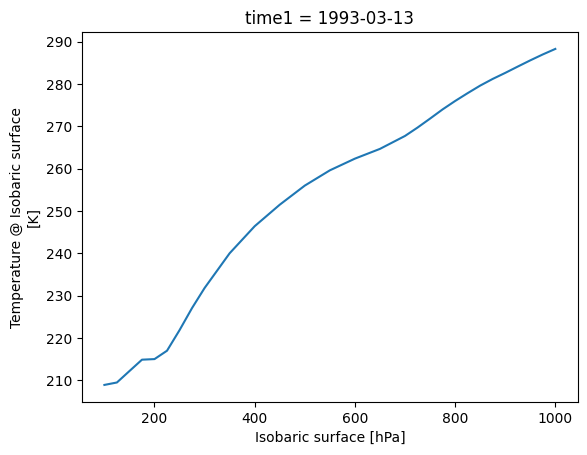

In [16]:
#Plotting with Xarray
prof.plot()

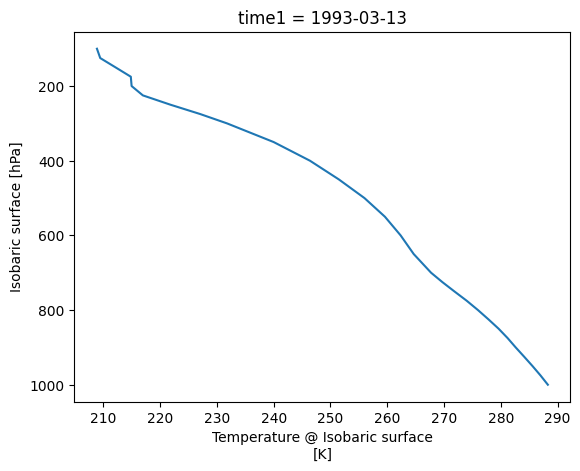

In [17]:
#Customizing the Plot
prof.plot(y="isobaric1",yincrease=False)

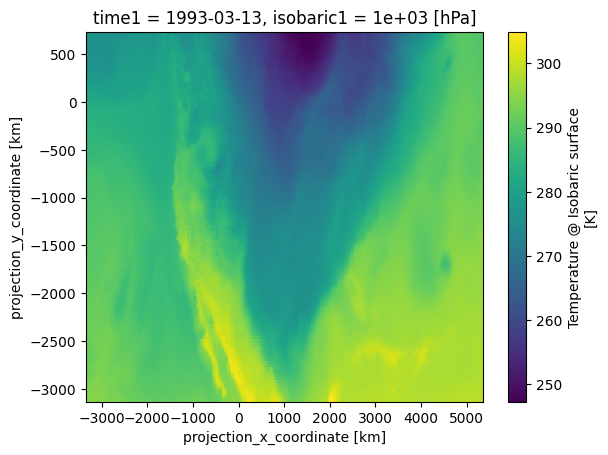

In [18]:
#Plotting 2D Data
temps.sel(isobaric1=1000).plot()

In [20]:
pip install cartopy

   ---------------------------------------- 0.0/11.0 MB ? eta -:--:--
    --------------------------------------- 0.3/11.0 MB ? eta -:--:--
   -- ------------------------------------- 0.8/11.0 MB 1.9 MB/s eta 0:00:06
   ---- ----------------------------------- 1.3/11.0 MB 2.1 MB/s eta 0:00:05
   ----- ---------------------------------- 1.6/11.0 MB 2.1 MB/s eta 0:00:05
   ------- -------------------------------- 2.1/11.0 MB 2.1 MB/s eta 0:00:05
   -------- ------------------------------- 2.4/11.0 MB 2.0 MB/s eta 0:00:05
   ---------- ----------------------------- 2.9/11.0 MB 2.1 MB/s eta 0:00:04
   ------------- -------------------------- 3.7/11.0 MB 2.2 MB/s eta 0:00:04
   --------------- ------------------------ 4.2/11.0 MB 2.2 MB/s eta 0:00:04
   ----------------- ---------------------- 4.7/11.0 MB 2.3 MB/s eta 0:00:03
   ------------------ --------------------- 5.0/11.0 MB 2.3 MB/s eta 0:00:03
   -------------------- ------------------- 5.5/11.0 MB 2.3 MB/s eta 0:00:03
   ----------

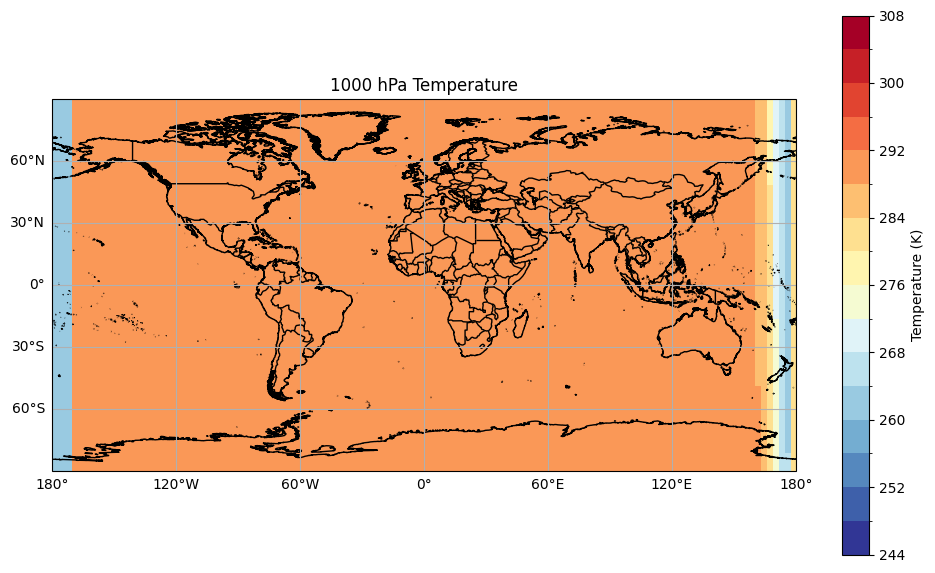

In [22]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

fig = plt.figure(figsize=(12,7))

ax = plt.axes(projection=ccrs.PlateCarree())

temps.sel(isobaric1=1000).plot(
    ax=ax,
    transform=ccrs.PlateCarree(),
    cmap="RdYlBu_r",
    levels=20,
    cbar_kwargs={"label":"Temperature (K)"}
)

ax.coastlines(resolution="10m")
ax.add_feature(cfeature.BORDERS)
ax.add_feature(cfeature.LAND)
ax.add_feature(cfeature.OCEAN)

gl = ax.gridlines(draw_labels=True)
gl.top_labels = False
gl.right_labels = False

ax.set_title("1000 hPa Temperature")

plt.show()